# Regime Detection with Hidden Markov Models

**Chapter 9 | Section 9.5**

**Docker image**: `ml4t`

A **regime** is a period during which the market behaves one way rather than another:
calm or stressed, trending or reverting. Nobody observes it. What a regime model does is
infer, from what is observable, which of a small number of unobserved states the market is
probably in now, and how likely it is to be in a different one tomorrow.

The distinction that matters more than the model is between an inference that uses only
what had happened by a given session and one that uses the whole sample. The second is
better in every way except the one that counts.

**Learning objectives**

- Build two regime indicators from observable quantities alone, and treat them as the bar
  any estimated model has to clear.
- Work through the recursion that infers a hidden state from observations one at a time,
  on an example small enough to check by hand.
- Say what separates that recursion's answer from the one that reads the whole sample, and
  measure the difference on real data.
- Fit the model to returns, handle the three things that go wrong when you do, and turn
  the result into columns.

**Book reference**

Chapter 9, Section 9.5 (Regime features).

**Prerequisites**

`01_visual_diagnostics` for stationarity. Probability and matrix multiplication.

## Setup

In [1]:
"""Regime detection with hidden Markov models - filtered inference and its features."""

import logging
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from hmmlearn.hmm import GaussianHMM
from IPython.display import display
from ml4t.engineer.features.regime import (
    choppiness_index,
    fractal_efficiency,
    hurst_exponent,
    market_regime_classifier,
    trend_intensity_index,
)
from ml4t.engineer.logging import setup_logging
from scipy import stats
from statsmodels.tools.sm_exceptions import ValueWarning
from statsmodels.tsa.regime_switching.markov_autoregression import MarkovAutoregression

from case_studies.utils.temporal import (
    filtered_state_probs,
    fit_hmm_kmeans_init,
    relabel_states,
    sort_states_by_variance,
)
from data import load_etfs, load_macro
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, FIGSIZE, show_with_alt

# The switching model indexes by position and warns once per fit that the date index it was
# handed carries no declared frequency. Trading days have none to declare.
warnings.filterwarnings("ignore", category=ValueWarning, module="statsmodels.tsa.base.tsa_model")
setup_logging(level=logging.ERROR)  # per-call timing notices from the indicator library

In [2]:
START_DATE = "2006-01-01"
END_DATE = "2024-12-31"
N_INITS = 10
N_ITER = 200
SEED = 42

In [3]:
set_global_seeds(SEED)

## The data

SPY daily bars with three derived series: the log return, a rolling standard deviation of
it, and a long moving average of the price. The first two are what the model reads; the
moving average is one of the two rules in Part 1.

A Gaussian model reading returns alone can already separate states that differ only in
variance, because two emissions with the same mean and different variances are two
different distributions. So that is not why the volatility column is here. It is here for
what it is: a summary of the last month rather than of one session, which makes the state
inferred at each session a statement about recent history and not about the latest return.

The frame keeps only sessions where all three are defined, which puts the first session
one moving-average window after the data begins. That window is the price of the rule in
Part 1: over those sessions the moving average is missing, and a comparison against a
missing value is false rather than missing, so a frame that kept them would report them as
sessions the price was not below its average.

In [4]:
VOLATILITY_WINDOW = 21
TREND_WINDOW = 200  # sessions in the long moving average: about ten months
SESSIONS_PER_YEAR = 252

spy = (
    load_etfs(symbols=["SPY"])
    .select(["timestamp", "open", "high", "low", "close", "volume"])
    .filter(pl.col("timestamp") <= pl.lit(END_DATE).str.to_date())
    .sort("timestamp")
    .with_columns(
        returns=pl.col("close").log().diff() * 100,
        volatility=pl.col("close").log().diff().rolling_std(VOLATILITY_WINDOW)
        * 100
        * np.sqrt(SESSIONS_PER_YEAR),
        moving_average=pl.col("close").rolling_mean(TREND_WINDOW),
    )
    .drop_nulls()
    .filter(pl.col("timestamp") >= pl.lit(START_DATE).str.to_date())
)

frame = spy.to_pandas().set_index("timestamp")
frame.index = pd.DatetimeIndex(frame.index)

print(f"SPY: {len(frame):,} sessions, {frame.index.min().date()} to {frame.index.max().date()}")
print(f"Sessions with a missing derived value: {int(frame.isna().sum().sum())}")

SPY: 4,582 sessions, 2006-10-17 to 2024-12-31
Sessions with a missing derived value: 0


# Part 1: what a rule can do without estimating anything

Two indicators, both computable by hand, both available the moment the data is. They are
not a warm-up: an estimated model that does not beat them is not worth its estimation
risk, and stating them first is what makes the rest of the notebook a comparison rather
than a demonstration.

The **volatility index** at a level is the classic stress rule. The index is the option
market's expectation of near-term volatility, so it is a forward-looking quantity nobody
has to fit, and a level around twenty has been the conventional line between calm and
stressed for decades.

A price against its own **long moving average** is the classic trend rule. Above the
average is an uptrend, below it a downtrend, and the only choice is the length.

In [5]:
VOLATILITY_INDEX_THRESHOLD = 20  # the conventional line between calm and stressed

macro = load_macro().select(["timestamp", "vixcls"]).drop_nulls().rename({"vixcls": "vix"})
vix = macro.to_pandas().set_index("timestamp")
vix.index = pd.DatetimeIndex(vix.index)

frame = frame.join(vix, how="left").ffill()
frame["stressed_by_index"] = (frame["vix"] > VOLATILITY_INDEX_THRESHOLD).astype(int)
frame["below_average"] = (frame["close"] < frame["moving_average"]).astype(int)

print(
    f"Sessions with the index above {VOLATILITY_INDEX_THRESHOLD}: {frame['stressed_by_index'].mean():.1%}"
)
print(f"Sessions below the {TREND_WINDOW}-session average: {frame['below_average'].mean():.1%}")
print(
    f"Sessions flagged by both: {(frame['stressed_by_index'] & frame['below_average']).mean():.1%}"
)

Sessions with the index above 20: 36.4%
Sessions below the 200-session average: 21.5%
Sessions flagged by both: 19.4%


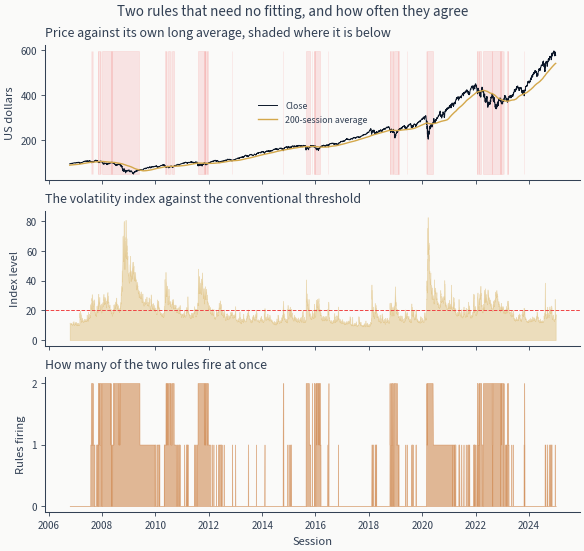

In [6]:
fig, axes = plt.subplots(3, 1, figsize=FIGSIZE["grid_3x2"], sharex=True)

ax = axes[0]
ax.plot(frame.index, frame["close"], linewidth=0.7, color=COLORS["blue"], label="Close")
ax.plot(
    frame.index,
    frame["moving_average"],
    linewidth=1,
    color=COLORS["amber"],
    label=f"{TREND_WINDOW}-session average",
)
ax.fill_between(
    frame.index,
    frame["close"].min(),
    frame["close"].max(),
    where=frame["below_average"] == 1,
    alpha=0.12,
    color=COLORS["negative"],
)
ax.set_ylabel("US dollars")
ax.set_title("Price against its own long average, shaded where it is below")
ax.legend(fontsize=7)

ax = axes[1]
ax.fill_between(frame.index, 0, frame["vix"], alpha=0.35, color=COLORS["amber"])
ax.axhline(VOLATILITY_INDEX_THRESHOLD, color=COLORS["negative"], linestyle="--", linewidth=0.7)
ax.set_ylabel("Index level")
ax.set_title("The volatility index against the conventional threshold")

ax = axes[2]
ax.fill_between(
    frame.index,
    0,
    frame["stressed_by_index"] + frame["below_average"],
    alpha=0.5,
    color=COLORS["copper"],
)
ax.set_yticks([0, 1, 2])
ax.set_ylabel("Rules firing")
ax.set_xlabel("Session")
ax.set_title("How many of the two rules fire at once")

fig.suptitle("Two rules that need no fitting, and how often they agree")
show_with_alt(
    fig,
    "Three stacked panels sharing a time axis. The top draws the SPY close with its "
    "200-session average and shades the periods below it, which cluster around 2008, 2020 "
    "and 2022. The middle draws the volatility index against a dashed line at twenty, which "
    "it exceeds in the same periods. The bottom is a step series counting how many of the "
    "two rules fire, reaching two during the same episodes.",
)

# Part 2: inferring a state you cannot see

A **hidden Markov model** has three parts. A small number of hidden states; a **transition
matrix** giving the probability of moving from each state to each other one; and an
**emission** distribution per state saying what observations that state tends to produce.
The states are never observed. What is observed is a sequence of numbers, and the model's
job is to say which state each of them probably came from.

The **forward algorithm** does that one observation at a time. It carries a probability
over states, advances it through the transition matrix, multiplies by how likely the new
observation is under each state, and renormalizes. What comes out at each step is
$P(\text{state}_t \mid \text{observations up to } t)$, which is called the **filtered**
probability and is the quantity a feature has to be.

The example below is ten observations from a two-state model whose parameters are known,
small enough to read off the printed table and check.

In [7]:
N_STATES_TOY = 2
TOY_LENGTH = 10

transition = np.array([[0.95, 0.05], [0.10, 0.90]])  # states are sticky in both directions
state_means = np.array([0.05, -0.10])  # calm drifts up, stressed drifts down
state_deviations = np.array([0.06, 0.08])  # and stressed is the more volatile
initial = np.array([0.8, 0.2])


def sample_toy_path(rng: np.random.Generator) -> tuple[np.ndarray, np.ndarray]:
    """One path of hidden states and the observations they emitted."""
    states = np.zeros(TOY_LENGTH, dtype=int)
    observations = np.zeros(TOY_LENGTH)
    states[0] = rng.choice(N_STATES_TOY, p=initial)
    observations[0] = rng.normal(state_means[states[0]], state_deviations[states[0]])
    for step in range(1, TOY_LENGTH):
        states[step] = rng.choice(N_STATES_TOY, p=transition[states[step - 1]])
        observations[step] = rng.normal(state_means[states[step]], state_deviations[states[step]])
    return states, observations


# A path that never switches state has nothing to illustrate, so the first seed whose path
# visits both is taken. The generator is local, so nothing else in the notebook moves.
for toy_seed in range(500):
    true_states, observations = sample_toy_path(np.random.default_rng(toy_seed))
    if true_states.min() == 0 and true_states.max() == 1:
        break

print(f"Hidden states: {true_states}")
print(f"Observations:  {np.round(observations, 4)}")

Hidden states: [0 0 0 0 0 0 0 0 1 1]
Observations:  [ 0.0186 -0.0965  0.1186  0.0964  0.0168  0.0314  0.0025  0.044  -0.1486
 -0.1714]


The recursion in two lines. Start with the initial distribution weighted by how likely
the first observation is under each state:

$$\alpha_1(k) = \pi_k\, b_k(o_1)$$

then advance:

$$\alpha_t(k) = b_k(o_t) \sum_{j} \alpha_{t-1}(j)\, A_{jk}$$

Normalizing $\alpha_t$ across states gives the filtered probability. Nothing after step
$t$ enters it, which is the whole point.

In [8]:
def forward_algorithm(
    observations: np.ndarray,
    transition: np.ndarray,
    means: np.ndarray,
    deviations: np.ndarray,
    initial: np.ndarray,
) -> np.ndarray:
    """Filtered state probabilities, one row per observation."""
    n_states = len(initial)
    alpha = np.zeros((len(observations), n_states))
    alpha[0] = initial * stats.norm.pdf(observations[0], means, deviations)
    for step in range(1, len(observations)):
        emission = stats.norm.pdf(observations[step], means, deviations)
        alpha[step] = emission * (alpha[step - 1] @ transition)
    return alpha / alpha.sum(axis=1, keepdims=True)


toy_filtered = forward_algorithm(observations, transition, state_means, state_deviations, initial)

display(
    pd.DataFrame(
        {
            "observation": np.round(observations, 4),
            "true state": true_states,
            "P(calm)": toy_filtered[:, 0].round(4),
            "P(stressed)": toy_filtered[:, 1].round(4),
            "most likely": toy_filtered.argmax(axis=1),
        }
    )
)
print(
    f"Sessions where the most likely state is the true one: {(toy_filtered.argmax(axis=1) == true_states).mean():.0%}"
)

,observation,true state,P(calm),P(stressed),most likely
0,0.0186,0,0.9332,0.0668,0
1,-0.0965,0,0.3618,0.6382,1
2,0.1186,0,0.9523,0.0477,0
3,0.0964,0,0.9951,0.0049,0
4,0.0168,0,0.9830,0.0170,0
5,0.0314,0,0.9861,0.0139,0
6,0.0025,0,0.9711,0.0289,0
7,0.0440,0,0.9881,0.0119,0
8,-0.1486,1,0.0950,0.9050,1
9,-0.1714,1,0.0005,0.9995,1


Sessions where the most likely state is the true one: 90%


## Filtered against smoothed

The **smoothed** probability $P(\text{state}_t \mid \text{all observations})$ answers a
different question: given everything that eventually happened, what state was the market
in at $t$? It is the better estimate of the past and it is unusable as a feature, because
at time $t$ the observations it conditions on had not happened.

The difference between the two is not a technicality. A smoothed probability rises before
a transition, because the observations after the transition tell it the transition was
coming. A model trained on that column learns to predict an event from a feature that
already knows the event happened.

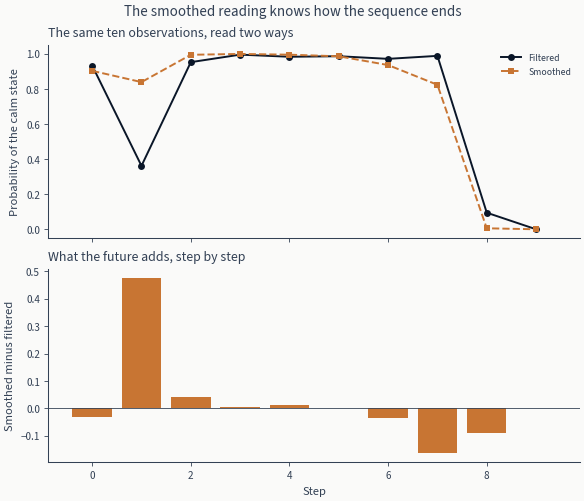

In [9]:
toy_hmm = GaussianHMM(n_components=N_STATES_TOY, covariance_type="diag", n_iter=1)
toy_hmm.startprob_ = initial
toy_hmm.transmat_ = transition
toy_hmm.means_ = state_means.reshape(-1, 1)
toy_hmm.covars_ = (state_deviations**2).reshape(-1, 1)

toy_smoothed = toy_hmm.predict_proba(observations.reshape(-1, 1))
toy_difference = toy_smoothed[:, 0] - toy_filtered[:, 0]

fig, axes = plt.subplots(2, 1, figsize=FIGSIZE["dual_v"], sharex=True)

steps = np.arange(TOY_LENGTH)
ax = axes[0]
ax.plot(steps, toy_filtered[:, 0], marker="o", markersize=5, color=COLORS["blue"], label="Filtered")
ax.plot(
    steps,
    toy_smoothed[:, 0],
    marker="s",
    markersize=5,
    linestyle="--",
    color=COLORS["copper"],
    label="Smoothed",
)
ax.set_ylim(-0.05, 1.05)
ax.ticklabel_format(useOffset=False, axis="y")
ax.set_ylabel("Probability of the calm state")
ax.set_title("The same ten observations, read two ways")
ax.legend(fontsize=7)

ax = axes[1]
ax.bar(steps, toy_difference, color=COLORS["copper"])
ax.axhline(0, color=COLORS["neutral"], linewidth=0.6)
ax.set_ylabel("Smoothed minus filtered")
ax.set_xlabel("Step")
ax.set_title("What the future adds, step by step")

fig.suptitle("The smoothed reading knows how the sequence ends")
show_with_alt(
    fig,
    "Two stacked panels over ten steps. The top plots the filtered and smoothed probability "
    "of the calm state; the two agree at most steps and separate around the transition, "
    "where the smoothed series has already moved and the filtered one has not. The bottom "
    "is a bar chart of the difference between them, near zero at most steps with a few "
    "large bars at and just before the transition.",
)

In [10]:
print(f"Mean absolute difference across the ten steps: {np.abs(toy_difference).mean():.4f}")
print(
    f"Largest at a single step: {np.abs(toy_difference).max():.4f}, at step {np.abs(toy_difference).argmax()}"
)

Mean absolute difference across the ten steps: 0.0854
Largest at a single step: 0.4770, at step 1


# Part 3: fitting it to returns

Three things go wrong when this model is estimated rather than given, and each has a
standard answer.

**The optimizer finds a local maximum.** Expectation-maximization climbs from wherever it
starts and stops at the first peak it reaches, so different starts give different models.
The answers are to start from several places and keep whichever reached the highest
likelihood, or to start somewhere sensible: a clustering of the observations puts the initial emission parameters near
where they will end up.

**The number of states is a choice.** More states always fit better, so the criterion has
to charge for them.

**The states have no order.** Nothing in the model says which state is which, so the same
fit run twice can return them swapped, and a feature built from a state label means
different things in different windows. The answer is to sort them by something the model
does define, here the size of each state's variance.

All four helpers below live in `case_studies.utils.temporal` rather than in this
notebook, because filtered inference in particular needs a private hmmlearn call that is
worth having in one place: `predict_proba` returns the smoothed posterior and there is no
public method that returns the emission term the forward recursion needs.

In [11]:
observations_matrix = frame[["returns", "volatility"]].to_numpy()
print(
    f"Observations: {observations_matrix.shape[0]:,} sessions, {observations_matrix.shape[1]} series"
)

Observations: 4,582 sessions, 2 series


In [12]:
restart_scores = []
for seed in range(N_INITS):
    restart = GaussianHMM(
        n_components=2, covariance_type="full", n_iter=N_ITER, random_state=seed, tol=1e-4
    ).fit(observations_matrix)
    restart_scores.append(restart.score(observations_matrix))

seeded = fit_hmm_kmeans_init(observations_matrix, n_states=2, random_state=SEED, n_iter=N_ITER)
seeded_score = seeded.score(observations_matrix)

display(
    pd.DataFrame(
        [
            {
                "start": f"{N_INITS} random starts",
                "best log-likelihood": max(restart_scores),
                "worst": min(restart_scores),
                "spread": max(restart_scores) - min(restart_scores),
            },
            {
                "start": "seeded from a clustering",
                "best log-likelihood": seeded_score,
                "worst": seeded_score,
                "spread": 0.0,
            },
        ]
    )
)

,start,best log-likelihood,worst,spread
0,10 random starts,-20717.960518,-20717.960568,0.00005
1,seeded from a clustering,-20717.971738,-20717.971738,0.00000


The spread across random starts is the size of the problem: it is how much of the fitted
log-likelihood is decided by where the optimizer happened to begin rather than by the
data. A seeded start reaches its answer once, which is not the same as reaching a better
one, and the two numbers beside each other say which happened here.

## How many states

The **Bayesian information criterion** charges each parameter a penalty that grows with
the sample size, and the smallest value picks the model. For a Gaussian model with $K$
states over $d$ series the parameter count is the initial distribution, the transition
matrix, the means and the covariances.

In [13]:
STATE_COUNTS = [2, 3, 4]


def parameter_count(n_states: int, n_series: int) -> int:
    """Free parameters of a Gaussian hidden Markov model with full covariances."""
    return (
        (n_states - 1)
        + n_states * (n_states - 1)
        + n_states * n_series
        + n_states * n_series * (n_series + 1) // 2
    )


n_sessions, n_series = observations_matrix.shape
fitted_models = {}
selection_rows = []
for n_states in STATE_COUNTS:
    candidate = fit_hmm_kmeans_init(
        observations_matrix, n_states=n_states, random_state=SEED, n_iter=N_ITER
    )
    fitted_models[n_states] = candidate
    parameters = parameter_count(n_states, n_series)
    selection_rows.append(
        {
            "states": n_states,
            "log-likelihood": candidate.score(observations_matrix),
            "parameters": parameters,
            "BIC": -2 * candidate.score(observations_matrix) + parameters * np.log(n_sessions),
        }
    )

selection = pd.DataFrame(selection_rows)
display(selection)
print(f"Lowest BIC at {selection.loc[selection['BIC'].idxmin(), 'states']} states")

,states,log-likelihood,parameters,BIC
0,2,-20717.971738,13,41545.532057
1,3,-18568.027341,23,37329.942171
2,4,-17347.301171,35,34989.648522


Lowest BIC at 4 states


The criterion's answer and the choice made here are not the same, and the reason is worth
stating rather than hiding. A criterion computed in sample rewards any structure the model
can fit, and on a long return series more states always find more volatility clustering to
describe. Whether those extra states are regimes a person could act on is a different
question that the criterion does not ask.

The rest of this notebook uses two states, on the grounds that calm and stressed is the
distinction the features are for and that a two-state fit is the one whose labels stay
interpretable when the model is refitted. That is a judgement about what the feature is
for, and it is stated so a reader can disagree with it.

In [14]:
N_STATES = 2

spy_hmm = fitted_models[N_STATES]
order = sort_states_by_variance(spy_hmm)
filtered = filtered_state_probs(spy_hmm, observations_matrix)[:, order]
smoothed = spy_hmm.predict_proba(observations_matrix)[:, order]
states, _ = relabel_states(spy_hmm.predict(observations_matrix), smoothed, order)

frame["filtered_stressed"] = filtered[:, -1]
frame["smoothed_stressed"] = smoothed[:, -1]
frame["state"] = filtered.argmax(axis=1)

display(
    frame.groupby("state").agg(
        sessions=("returns", "size"),
        share=("returns", lambda column: len(column) / len(frame)),
        mean_return=("returns", "mean"),
        mean_volatility=("volatility", "mean"),
    )
)

,sessions,share,mean_return,mean_volatility
state,,,,
0,2996,0.653863,0.069169,10.684906
1,1586,0.346137,-0.017118,26.580273


Sorting by variance is what makes the table above readable, and it is the step most
easily skipped. Without it the row labeled zero would be whichever state the optimizer
happened to number first, so the same column computed in two windows could carry opposite
meanings and a model reading it across a refit would learn nothing.

The hard state above is the argmax of the **filtered** probabilities rather than the
model's own `predict`, which runs the Viterbi algorithm over the whole sequence and
therefore reads the future. Two ways of labeling the same sessions, one of which is a
feature.

## The same difference, on real data

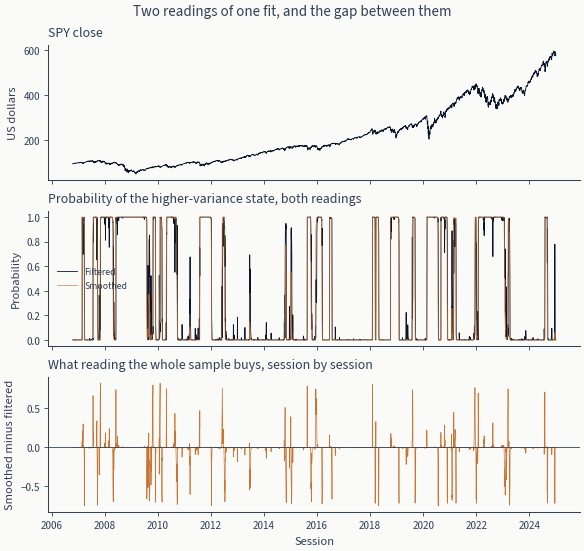

In [15]:
fig, axes = plt.subplots(3, 1, figsize=FIGSIZE["grid_3x2"], sharex=True)

ax = axes[0]
ax.plot(frame.index, frame["close"], linewidth=0.6, color=COLORS["blue"])
ax.set_ylabel("US dollars")
ax.set_title("SPY close")

ax = axes[1]
ax.plot(
    frame.index, frame["filtered_stressed"], linewidth=0.6, color=COLORS["blue"], label="Filtered"
)
ax.plot(
    frame.index,
    frame["smoothed_stressed"],
    linewidth=0.6,
    alpha=0.75,
    color=COLORS["copper"],
    label="Smoothed",
)
ax.set_ylabel("Probability")
ax.set_title("Probability of the higher-variance state, both readings")
ax.legend(fontsize=7)

ax = axes[2]
ax.plot(
    frame.index,
    frame["smoothed_stressed"] - frame["filtered_stressed"],
    linewidth=0.5,
    color=COLORS["copper"],
)
ax.axhline(0, color=COLORS["neutral"], linewidth=0.6)
ax.set_ylabel("Smoothed minus filtered")
ax.set_xlabel("Session")
ax.set_title("What reading the whole sample buys, session by session")

fig.suptitle("Two readings of one fit, and the gap between them")
show_with_alt(
    fig,
    "Three stacked panels sharing a time axis. The top draws the SPY close. The middle "
    "draws the filtered and smoothed probability of the higher-variance state, which agree "
    "for long stretches near zero and near one and separate at the edges of each stressed "
    "period. The bottom draws their difference, near zero most of the time with sharp "
    "excursions in both directions clustered at those edges.",
)

In [16]:
difference = frame["smoothed_stressed"] - frame["filtered_stressed"]
print(f"Mean absolute difference: {difference.abs().mean():.4f}")
print(f"Sessions where it exceeds a tenth: {(difference.abs() > 0.1).mean():.1%}")
print(
    "Sessions where the two disagree about which state is more likely: "
    f"{((frame['smoothed_stressed'] > 0.5) != (frame['filtered_stressed'] > 0.5)).mean():.1%}"
)

Mean absolute difference: 0.0367
Sessions where it exceeds a tenth: 8.4%
Sessions where the two disagree about which state is more likely: 3.6%


The two agree for most of the sample and disagree exactly where a feature would be used:
at the edges of a stressed period, where the smoothed reading has already turned and the
filtered one has not. The last line is the number to carry: on that share of sessions the
two readings would put the market in different states, and a backtest built on the
smoothed column gets those sessions right for free.

# Part 4: the columns

Four features come out of a fitted model, and they are different kinds of thing. The
probability changes every session. The transition probabilities and the expected duration
they imply are properties of the fit, so they change only when the model is refitted. The
entropy of the state distribution is the model's own statement about how sure it is,
which is the uncertainty feature `10_uncertainty_features` is about, available here for
free.

In [17]:
transition_matrix = spy_hmm.transmat_[order][:, order]
expected_duration = 1 / (1 - np.diag(transition_matrix))

display(
    pd.DataFrame(
        transition_matrix,
        index=[f"from state {k}" for k in range(N_STATES)],
        columns=[f"to state {k}" for k in range(N_STATES)],
    )
)
print(
    "Expected sessions in each state before leaving: "
    + ", ".join(f"state {k} {duration:.0f}" for k, duration in enumerate(expected_duration))
)

,to state 0,to state 1
from state 0,0.991549,0.008451
from state 1,0.016806,0.983194


Expected sessions in each state before leaving: state 0 118, state 1 60


In [18]:
frame["expected_duration"] = expected_duration[frame["state"].to_numpy()]
frame["state_entropy"] = -(filtered * np.log(np.clip(filtered, 1e-12, None))).sum(axis=1)

display(
    frame[["filtered_stressed", "state_entropy", "expected_duration"]]
    .describe()
    .loc[["mean", "std", "min", "max"]]
    .round(4)
)

,filtered_stressed,state_entropy,expected_duration
mean,0.3447,0.0521,97.9673
std,0.4595,0.1347,27.9882
min,0.0000,0.0000,59.5040
max,1.0000,0.6931,118.3287


The expected duration follows from the diagonal of the transition matrix and nothing
else: a state the model leaves with probability $p$ each session lasts $1/p$ sessions on
average. It takes exactly as many distinct values as there are states, so as a column it
is the state label wearing a unit, and it is worth carrying only where the model is
refitted often enough for the diagonal to move.

The entropy is the column with the most to say. It is near zero when the filtered
probability is close to zero or one and at its maximum when the model cannot tell, so it
marks the sessions on which the regime feature should not be trusted. A model given both
the probability and its entropy can learn to ignore the first when the second is high.

# Part 5: a second model of the same idea

**Markov switching autoregression** describes the same picture with a different mechanism.
Instead of a state that emits observations, it fits an autoregression whose variance, and
optionally whose coefficients, switch between regimes. It is estimated by maximum
likelihood rather than by expectation-maximization, and it produces the same two readings.

Fitting both is worth the cell it costs, because agreement between two differently
specified models is much better evidence that a regime is in the data than either one's
own confidence.

In [19]:
switching = MarkovAutoregression(
    frame["returns"], k_regimes=N_STATES, order=1, switching_ar=False, switching_variance=True
).fit(disp=False)

variances = np.array([switching.params[f"sigma2[{k}]"] for k in range(N_STATES)])
higher_variance_regime = int(np.argmax(variances))
print(f"Fitted variance by regime: {np.round(variances, 4)}")
print(f"The higher-variance regime is regime {higher_variance_regime}")

switching_filtered = switching.filtered_marginal_probabilities[higher_variance_regime]
frame["switching_stressed"] = switching_filtered.reindex(frame.index)

Fitted variance by regime: [0.4297 4.0156]
The higher-variance regime is regime 1


## Where the four readings agree

Four statements about the same sessions: the two rules from Part 1, the hidden Markov
model's filtered probability, and the switching model's. They are not measuring the same
thing. The index threshold reads an option market's expectation, the moving average reads
a trend, and the two fitted models read the size of recent moves. Agreement between them
is informative and disagreement is not an error in any of them.

In [20]:
comparison = frame[
    ["stressed_by_index", "below_average", "filtered_stressed", "switching_stressed"]
].dropna()
indicators = pd.DataFrame(
    {
        "volatility index above the threshold": comparison["stressed_by_index"].astype(bool),
        "price below its long average": comparison["below_average"].astype(bool),
        "hidden Markov model, filtered": comparison["filtered_stressed"] > 0.5,
        "switching model, filtered": comparison["switching_stressed"] > 0.5,
    }
)

display(
    pd.DataFrame(
        {
            "share of sessions flagged": indicators.mean(),
            "agreement with the hidden Markov model": indicators.apply(
                lambda column: (column == indicators["hidden Markov model, filtered"]).mean()
            ),
        }
    ).round(3)
)
print(f"Sessions flagged by all four: {indicators.all(axis=1).mean():.1%}")
print(f"Sessions flagged by none: {(~indicators).all(axis=1).mean():.1%}")

,share of sessions flagged,agreement with the hidden Markov model
volatility index above the threshold,0.364,0.858
price below its long average,0.215,0.843
"hidden Markov model, filtered",0.346,1.000
"switching model, filtered",0.290,0.855


Sessions flagged by all four: 16.5%
Sessions flagged by none: 54.6%


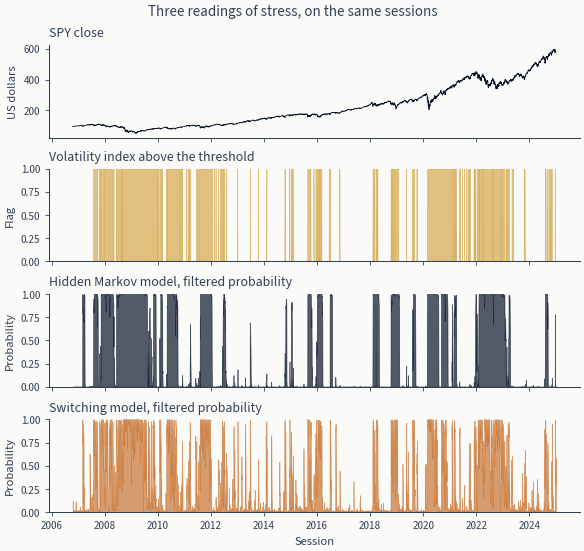

In [21]:
fig, axes = plt.subplots(4, 1, figsize=FIGSIZE["grid_3x2"], sharex=True)

ax = axes[0]
ax.plot(frame.index, frame["close"], linewidth=0.6, color=COLORS["blue"])
ax.set_ylabel("US dollars")
ax.set_title("SPY close")

for ax, column, color, title in [
    (axes[1], "stressed_by_index", COLORS["amber"], "Volatility index above the threshold"),
    (axes[2], "filtered_stressed", COLORS["blue"], "Hidden Markov model, filtered probability"),
    (axes[3], "switching_stressed", COLORS["copper"], "Switching model, filtered probability"),
]:
    ax.fill_between(frame.index, 0, frame[column].fillna(0), alpha=0.7, color=color)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Flag" if column == "stressed_by_index" else "Probability")
    ax.set_title(title)
axes[-1].set_xlabel("Session")

fig.suptitle("Three readings of stress, on the same sessions")
show_with_alt(
    fig,
    "Four stacked panels sharing a time axis. The top draws the SPY close. Below it, three "
    "filled series: a binary flag from the volatility index, and the filtered probabilities "
    "from the hidden Markov model and the switching model. All three fill in during 2008, "
    "2011, 2020 and 2022, with the two model-based series switching more often and more "
    "briefly than the index flag.",
)

# Part 6: regime without a model

`ml4t.engineer.features.regime` supplies indicators that classify a regime from price
structure alone, by fixed rules. They are deterministic, need no fitting, and are
available the same session. What they classify is a trend regime rather than a volatility
regime, so they answer a different question from the models above and the overlap between
them is a measurement rather than a validation.

In [22]:
INDICATOR_WINDOWS = {"choppiness": 14, "hurst": 100, "efficiency": 20, "trend": 30}

indicator_frame = (
    spy.with_columns(
        choppiness=choppiness_index("high", "low", "close", period=INDICATOR_WINDOWS["choppiness"]),
        hurst=hurst_exponent("close", period=INDICATOR_WINDOWS["hurst"]),
        efficiency=fractal_efficiency("close", period=INDICATOR_WINDOWS["efficiency"]),
        trend_intensity=trend_intensity_index("close", period=INDICATOR_WINDOWS["trend"]),
        classification=market_regime_classifier("high", "low", "close", "volume"),
    )
    .drop_nulls()
    .to_pandas()
    .set_index("timestamp")
)
indicator_frame.index = pd.DatetimeIndex(indicator_frame.index)

display(
    indicator_frame[["choppiness", "hurst", "efficiency", "trend_intensity"]]
    .describe()
    .loc[["mean", "std", "min", "max"]]
    .round(3)
)
print(
    "Share of sessions in each classification: "
    + ", ".join(
        f"{value} {share:.1%}"
        for value, share in indicator_frame["classification"].value_counts(normalize=True).items()
    )
)

,choppiness,hurst,efficiency,trend_intensity
mean,47.236,0.660,0.246,23.321
std,9.668,0.053,0.171,55.919
min,17.768,0.500,0.000,-75.221
max,77.796,0.828,0.847,87.567


Share of sessions in each classification: 0 90.5%, 1 4.8%, -1 4.7%


In [23]:
shared = frame.index.intersection(indicator_frame.index)
model_stressed = frame.loc[shared, "filtered_stressed"] > 0.5
classifier_bearish = indicator_frame.loc[shared, "classification"] == -1

print(f"Sessions the model calls stressed: {model_stressed.mean():.1%}")
print(f"Sessions the classifier calls bearish or range-bound: {classifier_bearish.mean():.1%}")
print(f"Sessions where the two agree: {(model_stressed == classifier_bearish).mean():.1%}")
joint = float((model_stressed & classifier_bearish).mean())
independent = float(model_stressed.mean() * classifier_bearish.mean())
print(f"Stressed and bearish together: {joint:.1%}")
print(f"What independence would give: {independent:.1%}")
print(f"Ratio of the two: {joint / independent:.2f}")

Sessions the model calls stressed: 35.2%
Sessions the classifier calls bearish or range-bound: 4.7%
Sessions where the two agree: 62.2%
Stressed and bearish together: 1.0%
What independence would give: 1.6%
Ratio of the two: 0.61


The agreement rate is the number to ignore. The two labels flag very different shares of
the sample, so most of their agreement is both saying no, and a rate above a half here
means almost nothing.

The last three lines are the ones with content, and they are worth reading twice. The two
labels co-occur *less* often than they would if they were unrelated. Whatever the model's
stressed state is picking up, it is not the same thing as the classifier's bearish label,
and the intuition that high volatility and a falling price go together does not survive
contact with these two definitions of them.

That is a reason to carry both rather than either. One says how large the moves are and
the other says which way they are going; a conditioning rule usually wants each
separately, and a single label that has collapsed them into one is the thing to avoid.

## The features this notebook produces

| Column | What it is | Causal |
|---|---|---|
| `filtered_stressed` | probability of the higher-variance state, from the forward recursion | in its inference, not in its parameters |
| `state` | which state that probability favours | same |
| `state_entropy` | how undecided the model is between states | same |
| `expected_duration` | how long the model expects the current state to last | a property of the fit |
| `switching_stressed` | the same probability from the switching model | same |
| `stressed_by_index`, `below_average` | the two rules from Part 1 | fully, they estimate nothing |

The middle column of that table needs its qualifier read. Every probability here is
filtered, so its **inference** uses only observations up to its own session. But the
**parameters** were estimated by fitting the model to the whole sample, so a session's
probability was produced by a transition matrix that had seen every later session. A
strictly point-in-time pipeline refits the model on each fold's training block and
extracts the filtered probabilities per fold, which is what
`case_studies/etfs/04_model_based_features.py` does and what a backtest should read.

This notebook keeps a single fit because the point being taught is the difference between
filtered and smoothed inference, and refitting per fold would put a second thing in the
same figure. Nothing here is written to disk, so nothing downstream can read a column
whose parameters saw its own future.

## Key takeaways

1. **Two rules that need no fitting set the bar.** An index threshold and a long moving
   average are transparent, immediate, and free of estimation risk. A fitted model earns
   its place by beating them at something.
2. **Filtered, never smoothed.** The forward recursion conditions on the past; the
   smoothed posterior conditions on everything. They disagree exactly at the transitions a
   regime feature exists to catch, and the notebook measures on what share of sessions.
3. **A hard label needs the same care as a probability.** The model's own `predict` runs
   a decode over the whole sequence, so a state label taken from it reads the future even
   when the probabilities beside it do not.
4. **Three things break a fitted regime model, and each has an answer.** Local optima,
   answered by seeded or repeated starts; the number of states, answered by a criterion
   that charges for them and then by judgement about what the feature is for; and the
   arbitrary ordering of states, answered by sorting them on something the model defines.
5. **Filtered inference is not the same as a point-in-time feature.** The parameters are
   fitted too, and a fit over the whole sample puts every later session into every earlier
   probability. Refitting per fold closes that, at the cost of one fit per fold, and
   `case_studies/etfs/04_model_based_features.py` is where it is done.

**Known limitations.** One symbol, one fit, one sample. The two-state choice is made
against the criterion rather than by it, on stated grounds a reader may reject. The
comparison between the model and the indicators measures overlap between two different
definitions of a regime and establishes nothing about either. And nothing here evaluates
whether a regime feature improves a downstream model, which is the only question that
decides whether any of it is worth carrying; `13_regime_as_feature` is where that is
asked.

**Next**: `12_wasserstein_regimes` clusters whole distributions instead of fitting a
state model, and `13_regime_as_feature` puts a regime probability into a model and
measures what it does.